In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import geopandas as gpd

from unidecode import unidecode

In [2]:
# parameters
region_level = "megye"
# region_level = "jaras"

In [3]:
# 1 -- distribution of MNEs
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_" + str(region_level) +".csv", sep=";")
region_gdf = gpd.read_file("../data/shape_files/" + str(region_level) + "_shape.geojson")
key_table = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")

In [4]:
# join region codes to shape
key_table = key_table.filter(regex=region_level).drop_duplicates()
key_column = str(region_level) + "_nev"
plot_df = pd.merge(
    region_gdf,
    key_table,
    left_on="region_name",
    right_on=key_column,
    how="left"
)

In [5]:
# aggregate MNE data
group_col = str(region_level) + "_kod"
region_mne_agg_table = mne_df.groupby(group_col)\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

region_mne_agg_table["mne_firm_share"] = region_mne_agg_table["nr_mnes"] / region_mne_agg_table["nr_firms"]
region_mne_agg_table["mne_emp_share"] = region_mne_agg_table["mne_emp"] / region_mne_agg_table["total_emp"]

In [6]:
# merge MNE data to map
key_col = str(region_level) + "_kod"
plot_df = pd.merge(
    plot_df,
    region_mne_agg_table,
    on=key_col,
    how="left"
)

In [7]:
def plot_mnes_on_map(df, key_var, colormap, label_text, fontsize, ax=None):
    """function to create map of MNE firms in Hungary"""
    if ax is None:
        ax = plt.gca()

    # map part    
    df.plot(column=key_var, cmap=colormap, edgecolor="white", linewidth=0.15, ax=ax)
    
    # colorbar
    vmin = df[key_var].min()
    vmax = df[key_var].max()
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, fraction=0.04, pad=0.0001, shrink=0.7, ax=ax)
    cbar.ax.set_ylabel(label_text, rotation=90, size=fontsize)
    cbar.ax.get_yaxis().labelpad = 5

    ax.axis('off')

# plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=14)

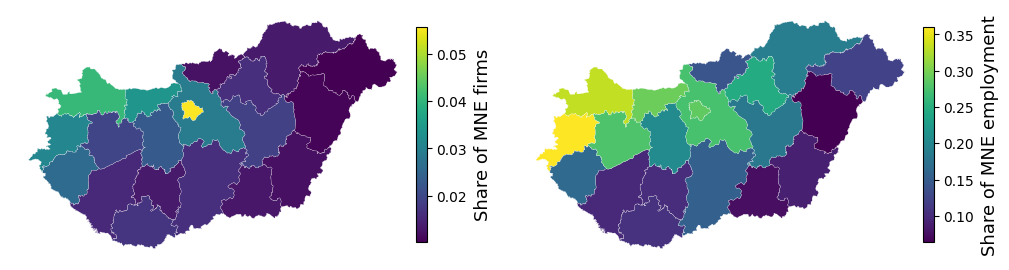

In [8]:
# grid of different plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_mnes_on_map(plot_df, key_var="mne_firm_share", colormap="viridis", label_text="Share of MNE firms", fontsize=13, ax=ax[0])
plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=13, ax=ax[1])

In [5]:
# MNEs per industry figure
mne_df["nace2d"] = mne_df["nace3d"] // 10
mne_ind_table = mne_df.groupby(["nace2d"])\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        nr_mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

mne_ind_table["share_mne_firms"] = mne_ind_table["nr_mnes"] / mne_ind_table["nr_firms"]
mne_ind_table["share_mne_emp"] = mne_ind_table["nr_mne_emp"] / mne_ind_table["total_emp"]

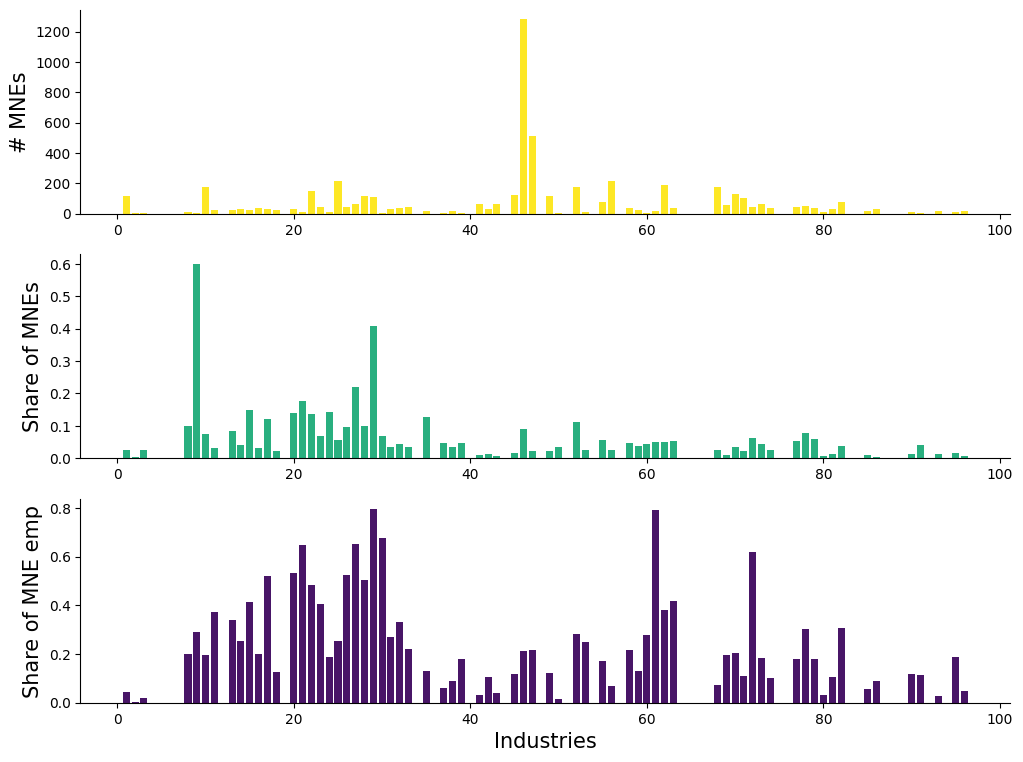

In [16]:
def plot_mne_per_industry(df, ind_col, key_col, color_code, ylabel_text, fontsize, xlabel_text=None, ax=None):
    """function to illustrate the distribution of MNEs across industries in Hungary"""
    if ax is None:
        ax = plt.gca()

    # plot
    ax.bar(df[ind_col], df[key_col], color=color_code)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel_text, size=fontsize)
    if xlabel_text is None:
        ax.set_xlabel("", size=fontsize)
    else:
        ax.set_xlabel(xlabel_text, size=fontsize)

fig = plt.figure(figsize=(12,9))
ax = [0]*3

gs = GridSpec(3,1, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[1,0])
ax[2] = fig.add_subplot(gs[2,0])
plot_mne_per_industry(mne_ind_table, "nace2d", "nr_mnes", color_code="#FDE725FF", ylabel_text="# MNEs", fontsize=15, ax=ax[0])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_firms", color_code="#29AF7FFF", ylabel_text="Share of MNEs", fontsize=15, ax=ax[1])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_emp", color_code="#481567FF", ylabel_text="Share of MNE emp", fontsize=15, xlabel_text="Industries", ax=ax[2])


In [ ]:
# network visual


In [ ]:
# illustration plot -- selected NUTS3
plot_df["selected_region"] = 0
plot_df.loc[plot_df["region_name"] == "Bacs-Kiskun", ["selected_region"]] = 1

fig, ax = plt.subplots(1,1, figsize=(6,5))
plot_df[plot_df["selected_region"]==1].plot(column="selected_region", color="#096607", ax=ax)
plot_df.boundary.plot(color="black", linewidth=0.25, ax=ax)

In [7]:
# coagg / IO / SR matrix visuals
el1 = pd.read_csv("../data/oc_2023_march_labor/m01_data_output_oc.csv", sep=";")

def norm01(values):
    new_values = (values - min(values)) / (max(values) - min(values))
    return new_values

def z_score(values):
    new_values = (values - np.mean(values)) / (max(values) - min(values))
    return new_values

In [83]:
# variables manipulation
el1["egk_coagg_norm"] = norm01(el1["egk_coagg"])
el1["egk_coagg_z"] = z_score(el1["egk_coagg"])

el1["log_undir_value"] = np.log10(el1["undir_value"])
el1.replace([np.inf, -np.inf], 0, inplace=True)

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


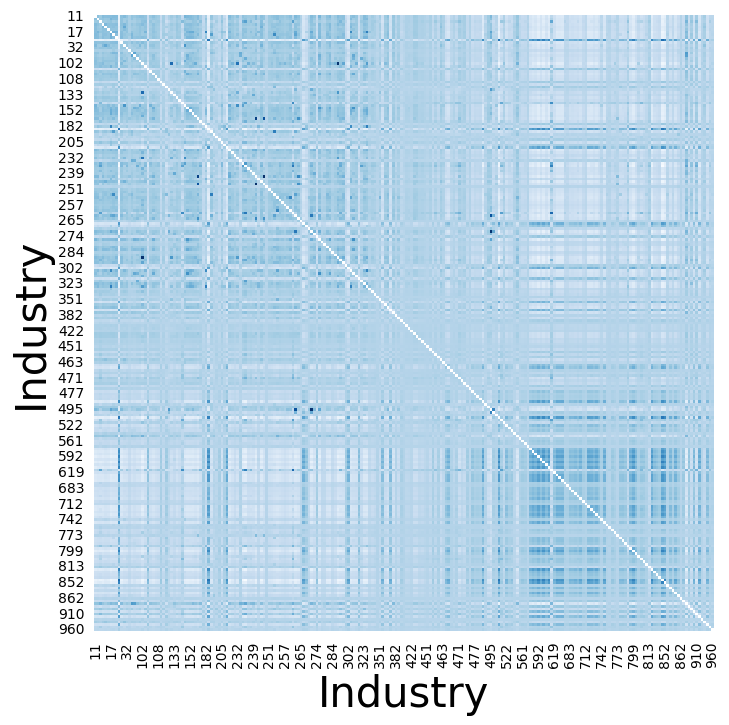

In [90]:
def mpp_matrix(df, key_cols, sort_matrix, heatmap, fontsize, cmap, ax=None):
    """matrix visualization"""
    table = df[key_cols]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_cols]
    table = pd.concat([table, table2])

    table = pd.pivot_table(table,
        values=key_cols[2],
        index=key_cols[0],
        columns=key_cols[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
     
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
  
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "egk_coagg_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Blues", ax=None)

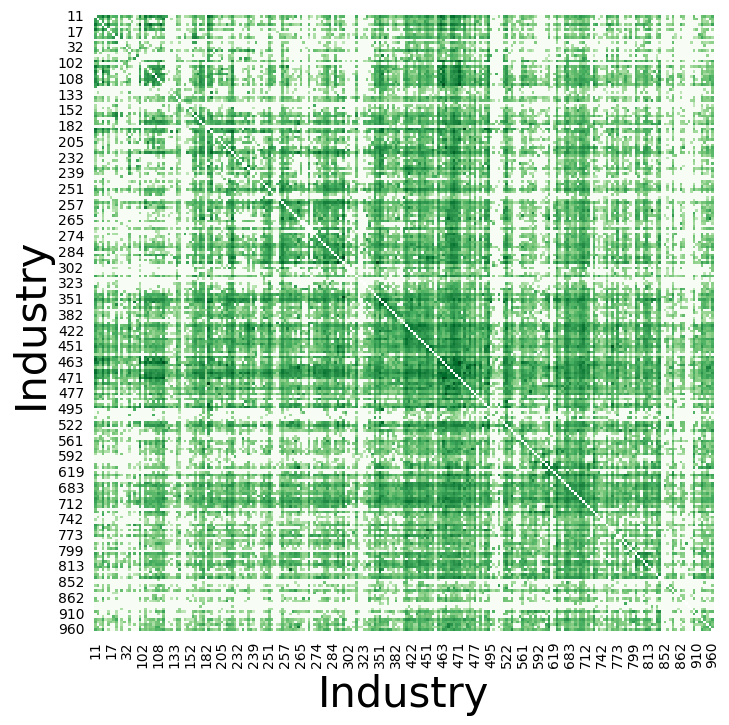

In [91]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "log_undir_value"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Greens", ax=None)

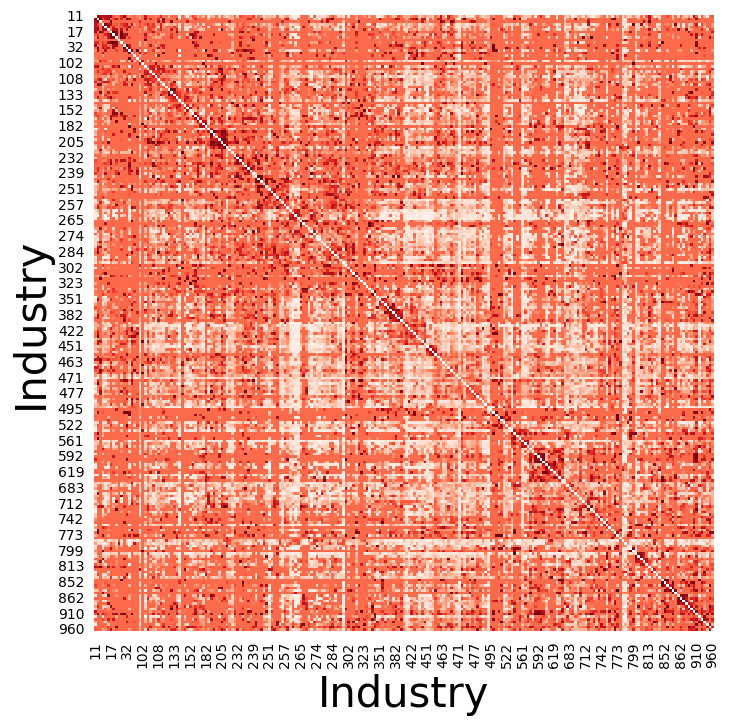

In [92]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "hun_sr_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Reds", ax=None)


(array([1.4700e+02, 2.1180e+03, 1.0850e+04, 1.2339e+04, 1.6630e+03,
        2.8800e+02, 7.2000e+01, 1.2000e+01, 2.0000e+00, 4.0000e+00]),
 array([-0.30194305, -0.20194305, -0.10194305, -0.00194305,  0.09805695,
         0.19805695,  0.29805695,  0.39805695,  0.49805695,  0.59805695,
         0.69805695]),
 <BarContainer object of 10 artists>)

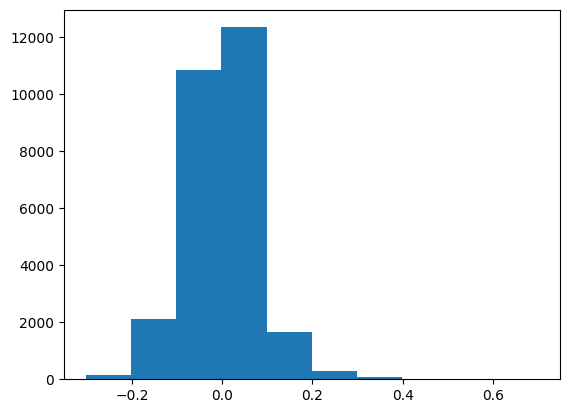

In [69]:
plt.hist(el1["egk_coagg_z"])

In [80]:
jarasok = gpd.read_file("../data/shape_files/admin7.shp")
keruletek = gpd.read_file("../data/shape_files/admin9.shp").sort_values("NAME")

knames = [
    "Budapest 01. ker.",
    "Budapest 02. ker.",
    "Budapest 03. ker.",
    "Budapest 04. ker.",
    "Budapest 09. ker.",
    "Budapest 05. ker.",
    "Budapest 06. ker.",
    "Budapest 07. ker.",
    "Budapest 08. ker.",
    "Budapest 10. ker.",
    "Budapest 11. ker.",
    "Budapest 12. ker.",
    "Budapest 13. ker.",
    "Budapest 14. ker.",
    "Budapest 19. ker.",
    "Budapest 15. ker.",
    "Budapest 16. ker.",
    "Budapest 17. ker.",
    "Budapest 18. ker.",
    "Budapest 20. ker.",
    "Budapest 21. ker.",
    "Budapest 22. ker.",
    "Budapest 23. ker.",
]

keruletek["NAME"] = knames

jarasok2 = pd.concat([jarasok, keruletek])

jarasok2["NAME"] = jarasok2["NAME"].str.replace(" járás", "")
jarasok2["NAME"] = jarasok2.apply(lambda r: unidecode(r["NAME"]), axis=1)

jarasok2 = jarasok2.rename(columns={"NAME": "region_name"})

jarasok2.to_file("../data/shape_files/jaras_shape.geojson", driver="GeoJSON")  

,NAME,ADMIN_LEVE,geometry
0,Letenyei,7,"POLYGON ((1842998.520 5859510.800, 1843189.820..."
1,Lenti,7,"POLYGON ((1821480.850 5906302.740, 1821599.060..."
2,Kormendi,7,"POLYGON ((1813564.040 5921326.370, 1813587.430..."
3,Szentgotthardi,7,"POLYGON ((1793789.650 5920727.330, 1793969.030..."
4,Zalaegerszegi,7,"POLYGON ((1836998.330 5915127.230, 1837059.620..."
...,...,...,...
8,Budapest 18. ker.,9,"POLYGON ((2132224.750 6014970.010, 2132427.560..."
6,Budapest 20. ker.,9,"POLYGON ((2124854.150 6014184.460, 2124978.290..."
4,Budapest 21. ker.,9,"POLYGON ((2117179.530 6005981.940, 2118192.650..."
2,Budapest 22. ker.,9,"POLYGON ((2109649.150 6006414.540, 2109666.720..."


In [68]:
jarasok2["NAME"] = jarasok2["NAME"].str.replace(" járás", "")
jarasok2["NAME"] = jarasok2.apply(lambda r: unidecode(r["NAME"]), axis=1)

In [69]:
jarasok2

,NAME,ADMIN_LEVE,geometry
0,Letenyei,7,"POLYGON ((1842998.520 5859510.800, 1843189.820..."
1,Lenti,7,"POLYGON ((1821480.850 5906302.740, 1821599.060..."
2,Kormendi,7,"POLYGON ((1813564.040 5921326.370, 1813587.430..."
3,Szentgotthardi,7,"POLYGON ((1793789.650 5920727.330, 1793969.030..."
4,Zalaegerszegi,7,"POLYGON ((1836998.330 5915127.230, 1837059.620..."
...,...,...,...
8,Budapest 18. ker.,9,"POLYGON ((2132224.750 6014970.010, 2132427.560..."
6,Budapest 20. ker.,9,"POLYGON ((2124854.150 6014184.460, 2124978.290..."
4,Budapest 21. ker.,9,"POLYGON ((2117179.530 6005981.940, 2118192.650..."
2,Budapest 22. ker.,9,"POLYGON ((2109649.150 6006414.540, 2109666.720..."


In [65]:
region_codes = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")
region_codes = region_codes[["jaras_kod", "jaras_nev"]].drop_duplicates()
region_codes

,jaras_kod,jaras_nev
0,999.0,"Budapest, illetve fiktiv teruleti egyseg"
22,116.0,Balassagyarmati
23,120.0,Salgotarjani
24,81.0,Martonvasari
25,55.0,Edelenyi
...,...,...
216,18.0,Budapest 18. ker.
217,9.0,Budapest 09. ker.
218,7.0,Budapest 07. ker.
219,23.0,Budapest 23. ker.


In [71]:
pd.merge(
    jarasok2,
    region_codes,
    left_on="NAME",
    right_on="jaras_nev",
    how="left"
)

,NAME,ADMIN_LEVE,geometry,jaras_kod,jaras_nev
0,Letenyei,7,"POLYGON ((1842998.520 5859510.800, 1843189.820...",195.0,Letenyei
1,Lenti,7,"POLYGON ((1821480.850 5906302.740, 1821599.060...",194.0,Lenti
2,Kormendi,7,"POLYGON ((1813564.040 5921326.370, 1813587.430...",177.0,Kormendi
3,Szentgotthardi,7,"POLYGON ((1793789.650 5920727.330, 1793969.030...",180.0,Szentgotthardi
4,Zalaegerszegi,7,"POLYGON ((1836998.330 5915127.230, 1837059.620...",197.0,Zalaegerszegi
...,...,...,...,...,...
193,Budapest 18. ker.,9,"POLYGON ((2132224.750 6014970.010, 2132427.560...",18.0,Budapest 18. ker.
194,Budapest 20. ker.,9,"POLYGON ((2124854.150 6014184.460, 2124978.290...",20.0,Budapest 20. ker.
195,Budapest 21. ker.,9,"POLYGON ((2117179.530 6005981.940, 2118192.650...",21.0,Budapest 21. ker.
196,Budapest 22. ker.,9,"POLYGON ((2109649.150 6006414.540, 2109666.720...",22.0,Budapest 22. ker.


In [30]:
pd.concat([jarasok, keruletek])

,NAME,ADMIN_LEVE,geometry
0,Letenyei járás,7,"POLYGON ((1842998.520 5859510.800, 1843189.820..."
1,Lenti járás,7,"POLYGON ((1821480.850 5906302.740, 1821599.060..."
2,Körmendi járás,7,"POLYGON ((1813564.040 5921326.370, 1813587.430..."
3,Szentgotthárdi járás,7,"POLYGON ((1793789.650 5920727.330, 1793969.030..."
4,Zalaegerszegi járás,7,"POLYGON ((1836998.330 5915127.230, 1837059.620..."
...,...,...,...
18,IV. kerület,9,"POLYGON ((2122550.720 6034481.710, 2122573.980..."
19,XV. kerület,9,"POLYGON ((2126505.870 6031048.960, 2126563.740..."
20,X. kerület,9,"POLYGON ((2126054.300 6020056.130, 2126410.250..."
21,XVI. kerület,9,"POLYGON ((2131199.080 6027912.640, 2131216.270..."


In [37]:
region_level = "jaras"
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_" + str(region_level) +".csv", sep=";")
mne_df

,jaras_kod,nace3d,mne_count,nr_firms,total_emp,emp_max_hozz,mne_emp,mne_emp_share,mne_dom_25,mne_dom_50,mne_dom_75
0,1,181,0,5,30,0.466667,0,0.000000,0,0,0
1,1,325,0,5,37,0.405405,0,0.000000,0,0,0
2,1,411,0,9,33,0.303030,0,0.000000,0,0,0
3,1,412,1,16,112,0.357143,6,0.053571,0,0,0
4,1,421,2,7,785,0.787261,696,0.886624,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
6867,197,951,0,6,24,0.291667,0,0.000000,0,0,0
6868,197,960,0,16,62,0.193548,0,0.000000,0,0,0
6869,198,256,0,5,35,0.600000,0,0.000000,0,0,0
6870,198,467,0,5,67,0.358209,0,0.000000,0,0,0


In [42]:
region_codes = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")
region_codes = region_codes[["jaras_kod", "jaras_nev"]].drop_duplicates()
region_codes

,jaras_kod,jaras_nev
0,999.0,"Budapest, illetve fiktiv teruleti egyseg"
22,116.0,Balassagyarmati
23,120.0,Salgotarjani
24,81.0,Martonvasari
25,55.0,Edelenyi
...,...,...
216,18.0,Budapest 18. ker.
217,9.0,Budapest 09. ker.
218,7.0,Budapest 07. ker.
219,23.0,Budapest 23. ker.


In [59]:
megye_df = gpd.read_file("../data/shape_files/hungary-nuts3-megye.geojson")
megye_df = megye_df[["NAME", "geometry"]]
megye_df["region_name"] = megye_df.apply(lambda r: unidecode(r["NAME"]), axis=1)
megye_df[["region_name", "megye"]] = megye_df["region_name"].str.split(expand=True)
megye_df = megye_df[["region_name", "geometry"]]
megye_df.to_file("../data/shape_files/hungary-nuts3-megye.geojson", driver="GeoJSON")




In [29]:
pd.merge(
    test,
    key_region_names[["jaras_nev", "jaras_kod"]].drop_duplicates(),
    left_on="Sheet1___1",
    right_on="jaras_nev",
    how="left"
)

,OBJECTID,Sheet1__ja,Sheet1___1,Shape_Leng,Shape_Area,geometry,jaras_nev,jaras_kod
0,1,24.0,Bólyi,88079.856424,2.200389e+08,"POLYGON ((606575.999 81204.002, 606599.999 812...",NaN,NaN
1,2,25.0,Hegyháti,150726.640580,3.607102e+08,"POLYGON ((595010.001 118410.998, 595193.001 11...",NaN,NaN
2,3,26.0,Komlói,124716.670949,2.924883e+08,"POLYGON ((593667.001 114321.999, 593712.001 11...",NaN,NaN
3,4,27.0,Mohácsi,194739.650411,6.009773e+08,"POLYGON ((612033.999 94746.001, 612259.999 945...",NaN,NaN
4,5,28.0,Pécsi,188405.251997,6.230981e+08,"POLYGON ((596464.000 97282.000, 596546.000 972...",NaN,NaN
...,...,...,...,...,...,...,...,...
170,171,195.0,Letenyei,118824.342947,3.886833e+08,"POLYGON ((482936.002 145279.995, 483006.002 14...",Letenyei,195.0
171,172,196.0,Nagykanizsai,180621.633764,9.078972e+08,"POLYGON ((493800.001 152944.005, 493816.001 15...",Nagykanizsai,196.0
172,173,197.0,Zalaegerszegi,207086.112929,1.044562e+09,"POLYGON ((482304.002 183871.002, 482586.002 18...",Zalaegerszegi,197.0
173,174,198.0,Zalaszentgróti,109611.093742,2.825396e+08,"POLYGON ((503057.000 188574.001, 503127.000 18...",NaN,NaN


In [32]:
test = gpd.read_file("../data/shape_files/hungary-nuts4-jaras.geojson")
test[test["Sheet1___1"].str.contains("Bólyi")]

,OBJECTID,Sheet1__ja,Sheet1___1,Shape_Leng,Shape_Area,geometry
0,1,24.0,Bólyi,88079.856424,2.200389e+08,"POLYGON ((606575.999 81204.002, 606599.999 812..."


In [42]:
key_region_names[key_region_names["jaras_nev"]=="Bolyi"]
#key_region_names["jaras_nev"].str.contains("Bolyi").isna().sum()

,jaras_kod,jaras_nev,megye_kod,megye_nev
121,24.0,Bolyi,2.0,Baranya


In [2]:
# load data
ir_df = pd.read_csv("../data/oc_2022_november/indreg_2018_2020_megye.csv", sep=";")
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_megye.csv", sep=";")
coa_df = pd.read_csv("../data/oc_2023_january/oc_m01_data_output_megye.csv", sep=";")

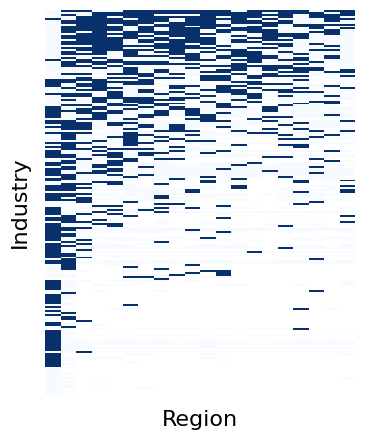

In [11]:
def mcp_matrix(df, key_cols, heatmap, fontsize, ax=None):
    table = df[key_cols]
    table.loc[table["rca18"] >=1, ["rca18"]] = 1
    table.loc[table["rca18"] < 1, ["rca18"]] = 0
    
    table = pd.pivot_table(table,
        values="rca18",
        index=["ind"],
        columns=["reg"],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
        
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        ax.set_xlabel("Region", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
        
fig, ax = plt.subplots(1,1, figsize=(4,5))
mcp_matrix(ir_df, key_cols=["reg", "ind", "rca18"], fontsize=16, heatmap=True)

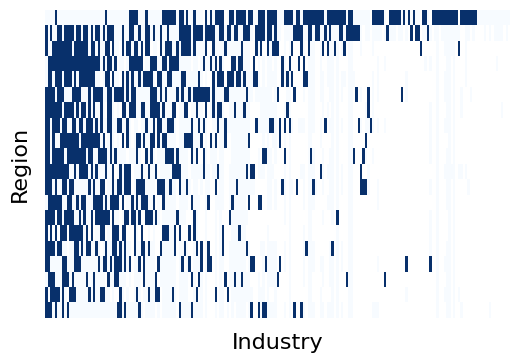

In [15]:
def t_mcp_matrix(df, key_cols, heatmap, fontsize, ax=None):
    table = df[key_cols]
    table.loc[table["rca18"] >=1, ["rca18"]] = 1
    table.loc[table["rca18"] < 1, ["rca18"]] = 0
    
    table = pd.pivot_table(table,
        values="rca18",
        index=["reg"],
        columns=["ind"],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
        
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Region", size=fontsize)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
        
fig, ax = plt.subplots(1,1, figsize=(6,4))
t_mcp_matrix(ir_df, key_cols=["reg", "ind", "rca18"], fontsize=16, heatmap=True)

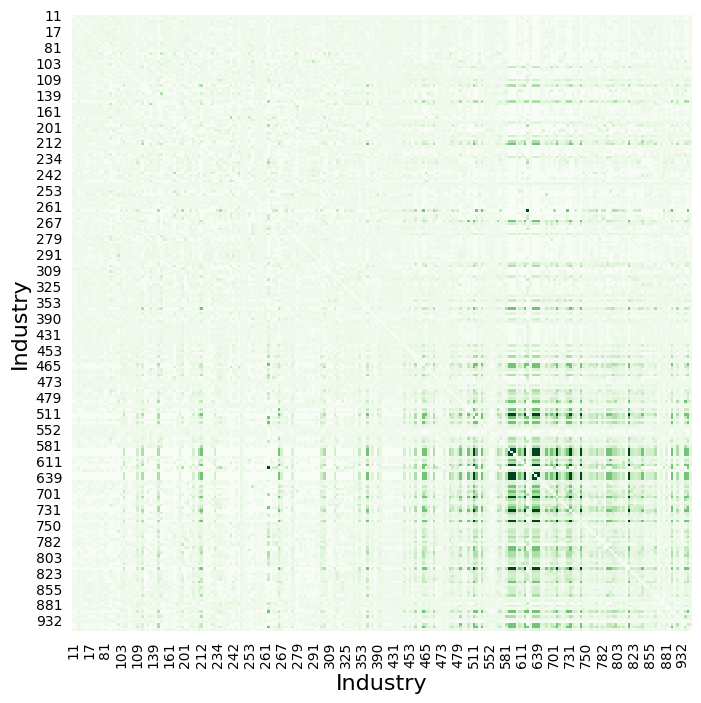

In [53]:
def mpp_matrix(df, key_cols, heatmap, fontsize, cmap, ax=None):
    table = df[key_cols]
    
    table = pd.pivot_table(table,
        values=key_cols[2],
        index=key_cols[0],
        columns=key_cols[1],
        aggfunc=np.mean,
        margins=True,
        margins_name='total')

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)
  
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg"], heatmap=True, fontsize=16, cmap="Greens", ax=None)


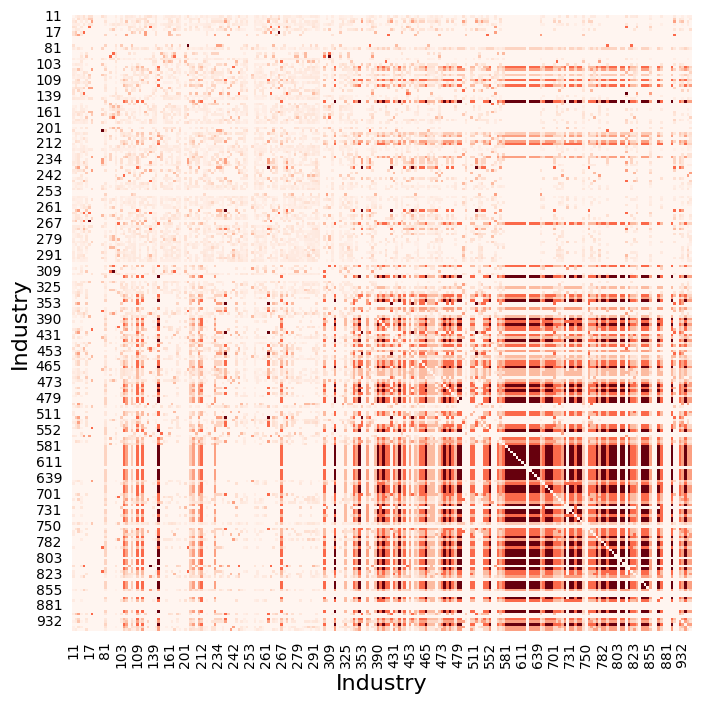

In [56]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg_mne"], heatmap=True, fontsize=16, cmap="Reds", ax=None)

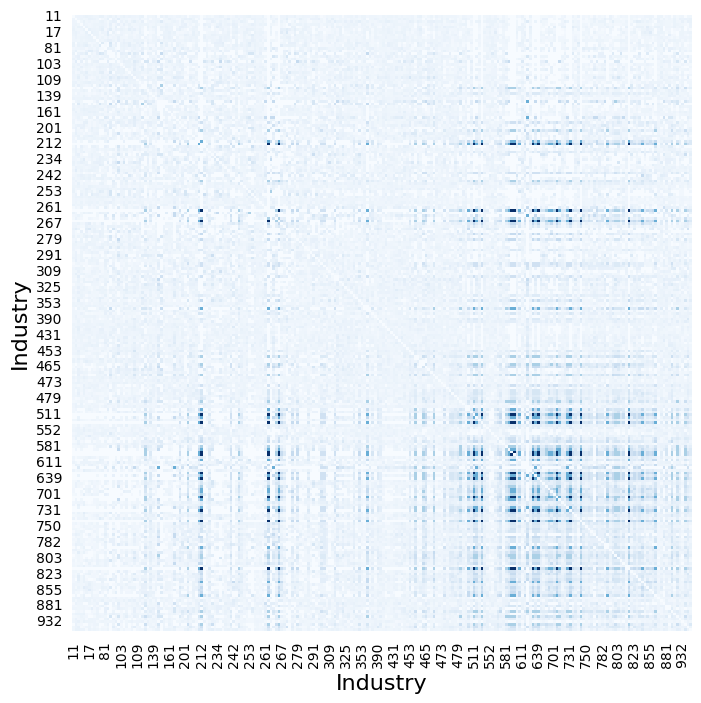

In [57]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg_local"], heatmap=True, fontsize=16, cmap="Blues", ax=None)

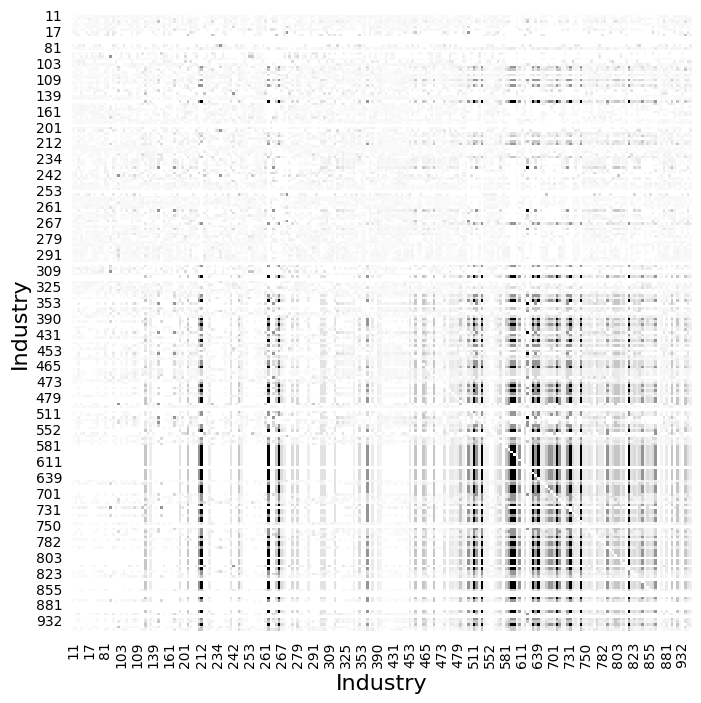

In [62]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(coa_df, key_cols=["ind1", "ind2", "coagg_mne_local"], heatmap=True, fontsize=16, cmap="Greys", ax=None)

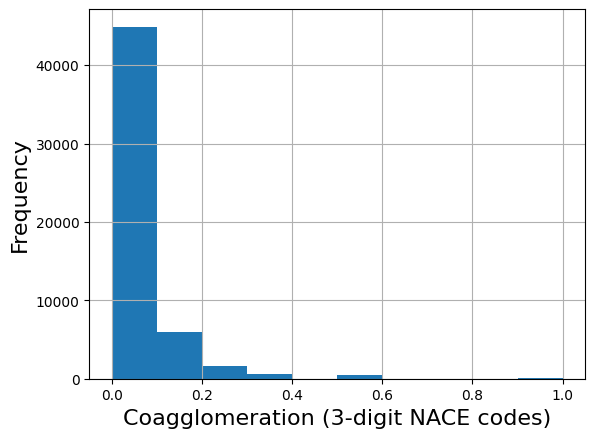

In [13]:
fontsize = 16
plt.hist(coa_df["coagg"])
plt.xlabel("Coagglomeration (3-digit NACE codes)", size=fontsize)
plt.ylabel("Frequency", size=fontsize)
#plt.semilogy()
plt.grid()